In [1]:
import pandas as pd

df = pd.read_csv('data/raw/datos_crudos.csv')
df.head()


,Unnamed: 0,fecha_reporte_web,id_de_caso,fecha_de_notificaci_n,departamento,departamento_nom,ciudad_municipio,ciudad_municipio_nom,edad,unidad_medida,...,recuperado,fecha_inicio_sintomas,fecha_muerte,fecha_diagnostico,per_etn_,fecha_recuperado,tipo_recuperacion,nom_grupo_,pais_viajo_1_cod,pais_viajo_1_nom
0,0,2020-05-03 00:00:00,7597,2020-04-29 00:00:00,11,BOGOTA,11001,BOGOTA,69,1,...,Recuperado,2020-04-24 00:00:00,NaN,2020-05-03 00:00:00,5.0,2020-05-29 00:00:00,PCR,NaN,NaN,NaN
1,1,2020-05-13 00:00:00,12537,2020-05-07 00:00:00,91,AMAZONAS,91001,LETICIA,51,1,...,Recuperado,2020-05-03 00:00:00,NaN,2020-05-13 00:00:00,1.0,2020-06-04 00:00:00,Tiempo,TIKUNA,NaN,NaN
2,2,2020-05-13 00:00:00,12869,2020-05-08 00:00:00,11,BOGOTA,11001,BOGOTA,72,1,...,Recuperado,2020-05-08 00:00:00,NaN,2020-05-13 00:00:00,6.0,2020-05-23 00:00:00,PCR,NaN,NaN,NaN
3,3,2020-06-13 00:00:00,47472,2020-05-29 00:00:00,13001,CARTAGENA,13001,CARTAGENA,31,1,...,Recuperado,2020-05-25 00:00:00,NaN,2020-06-13 00:00:00,6.0,2020-06-26 00:00:00,PCR,NaN,NaN,NaN
4,4,2020-06-20 00:00:00,64066,2020-06-16 00:00:00,11,BOGOTA,11001,BOGOTA,26,1,...,Recuperado,2020-06-05 00:00:00,NaN,2020-06-20 00:00:00,6.0,2020-07-04 00:00:00,PCR,NaN,NaN,NaN


Ahora, voy a responder unas preguntas con los datos quetengo....

In [2]:
df['fecha_reporte_web'].dtype
#df['fecha_reporte_web']=pd.to_datetime(df['fecha_reporte_web'])
print(df['fecha_reporte_web'].dtype)
df1=df["fecha_reporte_web"].value_counts().sort_index()

df1

str


fecha_reporte_web
2020-03-28 00:00:00    1
2020-03-29 00:00:00    1
2020-03-30 00:00:00    1
2020-04-01 00:00:00    1
2020-04-02 00:00:00    1
                      ..
2023-12-20 00:00:00    3
2023-12-26 00:00:00    1
2024-01-03 00:00:00    5
2024-01-10 00:00:00    2
2024-01-17 00:00:00    6
Name: count, Length: 812, dtype: int64

In [20]:
#df1=df1.sort_values()
#print(df1.columns)
#df1=df1.rename(columns={"Unnamed: 0":"datos-POR-fecha"})


Inicialmente: 

En que fehcasx ocurrieron los picos de pandemia

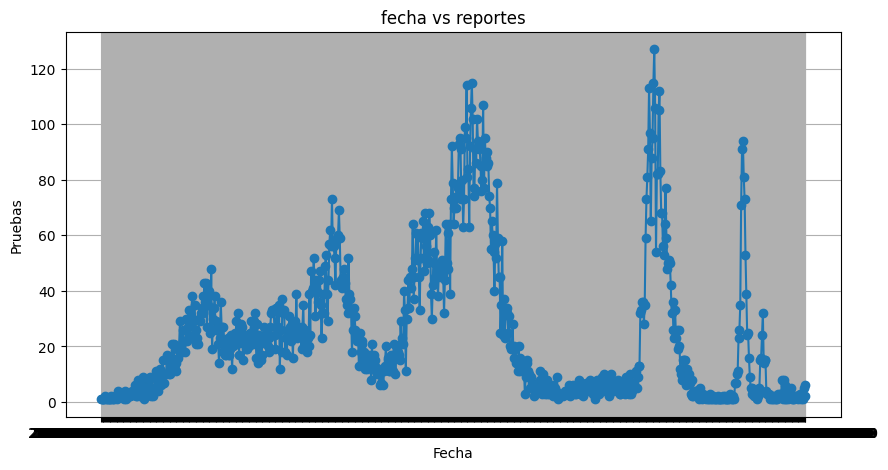

In [3]:
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('default')
x=df1

x1=x.index.tolist()
y1=x.tolist()

plt.figure(figsize=(10,5), facecolor='white')
plt.plot(x1, y1, marker='o')
plt.title('fecha vs reportes')
plt.xlabel('Fecha')
plt.ylabel('Pruebas')
plt.grid(True)
plt.show()




Ahora, veremos como varia la cantidad de muertes a traves del tiempo

In [5]:
df.columns

Index(['Unnamed: 0', 'fecha_reporte_web', 'id_de_caso',
       'fecha_de_notificaci_n', 'departamento', 'departamento_nom',
       'ciudad_municipio', 'ciudad_municipio_nom', 'edad', 'unidad_medida',
       'sexo', 'fuente_tipo_contagio', 'ubicacion', 'estado', 'recuperado',
       'fecha_inicio_sintomas', 'fecha_muerte', 'fecha_diagnostico',
       'per_etn_', 'fecha_recuperado', 'tipo_recuperacion', 'nom_grupo_',
       'pais_viajo_1_cod', 'pais_viajo_1_nom'],
      dtype='str')

Primero buscamos que porcentaje de los casos en toda la pandemia son fallecidos


In [6]:
# BUSCAMOS LOS VALORES UNICOS DE LA COLUMNA "estado"
print('los valores unicos de la columna "estado" son:',df['estado'].unique())

# MEDIANTE UN GROUPBY SACAREMOS ESTAS CANTIDADES
df2=df
print(df2['estado'].dtype)
df2=df2['estado'].value_counts()
df2




los valores unicos de la columna "estado" son: <StringArray>
['Leve', 'Fallecido', 'leve', nan, 'Moderado']
Length: 5, dtype: str
str


estado
Leve         19264
Fallecido      459
leve           156
Moderado         4
Name: count, dtype: int64

Primero buscamos que porcentaje de los reportes son fallecidos

In [7]:
df3=df

df3=df.groupby(["fecha_reporte_web", "estado"]).size()
print(df3)




fecha_reporte_web    estado   
2020-03-28 00:00:00  Leve         1
2020-03-29 00:00:00  Leve         1
2020-03-30 00:00:00  Fallecido    1
2020-04-01 00:00:00  Leve         1
2020-04-02 00:00:00  Leve         1
                                 ..
2024-01-03 00:00:00  Moderado     1
2024-01-10 00:00:00  Leve         1
                     Moderado     1
2024-01-17 00:00:00  Leve         5
                     Moderado     1
Length: 1137, dtype: int64


In [8]:
df3=df3.to_frame()

df3 = df3.reset_index()
df3=df3[['fecha_reporte_web','estado',0]]
df3.columns


Index(['fecha_reporte_web', 'estado', 0], dtype='object')

Ahora, vamos a sacar los fallecidos por fecha

In [9]:
#df3=df3[df3['estado']=='Fallecido']
df_fallecidos = df3[df3["estado"] == "Fallecido"]
df_fallecidos

,fecha_reporte_web,estado,0
2,2020-03-30 00:00:00,Fallecido,1
28,2020-05-13 00:00:00,Fallecido,1
37,2020-05-23 00:00:00,Fallecido,1
50,2020-06-04 00:00:00,Fallecido,1
59,2020-06-12 00:00:00,Fallecido,1
...,...,...,...
1059,2022-08-25 00:00:00,Fallecido,1
1069,2022-10-13 00:00:00,Fallecido,1
1078,2022-12-15 00:00:00,Fallecido,1
1083,2023-01-05 00:00:00,Fallecido,2


In [10]:
x3=df_fallecidos['fecha_reporte_web']
x2=df_fallecidos[0]





NameError: name 'x3' is not defined

<Figure size 1000x500 with 0 Axes>

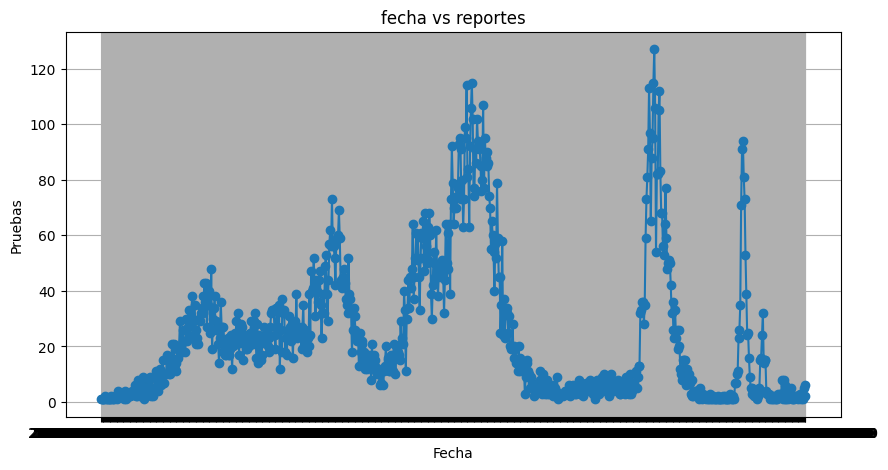

In [4]:
import matplotlib
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))


plt.figure(figsize=(10,5))
plt.plot(x1, y1, marker='o')
plt.title('fecha vs reportes')
plt.xlabel('Fecha')
plt.ylabel('Pruebas')
plt.grid(True)



plt.scatter(x3, x2, color='red',marker='o')
plt.title('fecha vs reportes')
plt.xlabel('Fecha')
plt.ylabel('fallecidos')
plt.grid(True)
plt.show()